# CS224N · Lecture 2 — Word Vectors, Word Senses, and Neural Classifiers

**Slides:** [cs224n-spr2024-lecture02-wordvecs2.pdf](https://web.stanford.edu/class/cs224n/slides/cs224n-spr2024-lecture02-wordvecs2.pdf)  
**Prerequisite:** the Lecture 1 notebook (skip-gram, softmax, gradient descent).

### Goal of the lecture
> **Be able to read and understand word-embedding papers.**

### What you will learn here
| § | Topic | You will implement |
|---|---|---|
| 1 | Optimization recap (+ 🔎 momentum and Adam) | GD vs momentum vs Adam |
| 2 | word2vec, reviewed as matrices; "bag of words" | — |
| 3 | Skip-gram vs CBOW; **negative sampling**; sparse updates | SGNS from scratch + gradient check; PyTorch version |
| 4 | Count-based methods: co-occurrence matrices, SVD, scaling hacks | Co-occurrence matrix from the slides, PPMI + SVD |
| 5 | **GloVe** | GloVe from scratch (AdaGrad) |
| 6 | Evaluating word vectors (intrinsic vs extrinsic) | Analogy and similarity evaluation |
| 7 | Word senses and ambiguity | Context clustering; testing the "linear superposition" result |
| 8 | Classification review; NER; cross-entropy | Softmax classifier, window features |
| 9 | Neural networks as stacked logistic regressions | Window-based neural NER classifier (PyTorch) |

In [8]:
! pip install torch

  Using cached torch-2.14.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (39 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.7-py3-none-any.whl.metadata (6.7 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.14.1-cp314-cp314-macosx_14_0_arm64.whl (127.3 MB)
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
Using cached networkx-3.7-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torch]32m5/6 [torch]]x]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random, collections
from scipy.stats import spearmanr
import torch
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)
random.seed(0)

def softmax(x, axis=-1):
    z = x - x.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

---
## 1. Optimization recap: gradient descent and SGD

Same material as the end of Lecture 1:
* **Gradient descent:** $\theta^{\text{new}} = \theta^{\text{old}} - \alpha\nabla_\theta J(\theta)$, with $\alpha$ the learning rate.
* $J(\theta)$ sums over *all* windows in the corpus (billions), so a full gradient is far too expensive per step.
* **Stochastic / mini-batch gradient descent:** sample a window (or a mini-batch of windows), compute the gradient on just that, update, repeat.

### 🔎 Beyond the slides: momentum and Adam
Plain SGD is rarely used to train modern networks; Assignment 2 onward uses **Adam**. You should know these update rules by heart:

**SGD with momentum** keeps a running "velocity", so consistent gradient directions accelerate and oscillating directions cancel:
$$m \leftarrow \beta m + \nabla_\theta J,\qquad \theta \leftarrow \theta - \alpha m$$

**Adam** (Kingma & Ba 2015) also keeps a running average of *squared* gradients and divides by its square root, giving every parameter its own adaptive step size:
$$m \leftarrow \beta_1 m + (1-\beta_1) g,\quad v \leftarrow \beta_2 v + (1-\beta_2) g^2,\quad \hat m = \tfrac{m}{1-\beta_1^t},\ \hat v = \tfrac{v}{1-\beta_2^t},\quad \theta \leftarrow \theta - \alpha\frac{\hat m}{\sqrt{\hat v}+\epsilon}$$

Defaults: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$. The bias corrections $\hat m, \hat v$ matter at the start, when $m, v$ are still near their zero initialization. (Its cousin **AdamW** decouples weight decay from the gradient and is the default for Transformers.)

Adaptive steps are especially useful in NLP because word frequencies are extremely skewed: rare words' embeddings get few, small gradients, and per-parameter scaling helps them learn.

In [ ]:
def J_bowl(th):    return 0.5 * (th[0]**2 + 10 * th[1]**2)
def grad_bowl(th): return np.array([th[0], 10 * th[1]])

def run(optimizer, steps=60, start=(-9.0, 2.5)):
    th = np.array(start); path = [th.copy()]; state = {}
    for t in range(1, steps + 1):
        th = optimizer(th, grad_bowl(th), state, t)
        path.append(th.copy())
    return np.array(path)

def sgd(th, g, s, t, lr=0.09):
    return th - lr * g

def momentum(th, g, s, t, lr=0.03, beta=0.8):
    s["m"] = beta * s.get("m", 0) + g
    return th - lr * s["m"]

def adam(th, g, s, t, lr=0.8, b1=0.9, b2=0.999, eps=1e-8):
    s["m"] = b1 * s.get("m", 0) + (1 - b1) * g
    s["v"] = b2 * s.get("v", 0) + (1 - b2) * g**2
    m_hat, v_hat = s["m"] / (1 - b1**t), s["v"] / (1 - b2**t)
    return th - lr * m_hat / (np.sqrt(v_hat) + eps)

xs, ys = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-4, 4, 200))
plt.figure(figsize=(8, 4))
plt.contour(xs, ys, 0.5 * (xs**2 + 10 * ys**2), levels=20, cmap="Greys", linewidths=0.5)
for opt, c in [(sgd, "crimson"), (momentum, "navy"), (adam, "green")]:
    p = run(opt)
    plt.plot(p[:, 0], p[:, 1], "o-", ms=2, color=c, label=f"{opt.__name__}: J after 60 steps = {J_bowl(p[-1]):.2e}")
plt.legend(); plt.title("Same ill-conditioned bowl, three optimizers"); plt.show()

---
## 2. Review: the main idea of word2vec

* Start with **random** word vectors.
* Iterate through each word position in the whole corpus.
* Try to predict surrounding words using word vectors: $P(o\mid c) = \dfrac{\exp(u_o^\top v_c)}{\sum_{w\in V}\exp(u_w^\top v_c)}$.
* **Learning:** update the vectors so they predict the actual surrounding words better.

Doing no more than this, the algorithm learns vectors that capture word similarity *and* meaningful **directions** in the space.

### 2.1 The computation as matrices
Store outside vectors as rows of $U\in\mathbb{R}^{|V|\times d}$ and center vectors as rows of $V\in\mathbb{R}^{|V|\times d}$. For center word $c$:

$$\underbrace{U}_{|V|\times d}\ \underbrace{v_c}_{d} = \text{scores (dot products) for every word} \quad\xrightarrow{\ \text{softmax}\ }\quad \text{probabilities } P(\cdot\mid c)$$

### 2.2 It's a "bag of words" model
**The model makes the same prediction at each position** in the window: $P(\cdot\mid c)$ doesn't know whether it's predicting the word one to the left or three to the right. It doesn't model word order at all. We want a model that gives a reasonably high probability to *all* words that occur in the context (at all often). Order-aware models come later (RNNs in L5, Transformers in L8).

### 2.3 How word2vec places similar words nearby
If "cat" and "dog" both appear with *ate, slept, ran, the*, then to predict those contexts well, $v_{\text{cat}}$ and $v_{\text{dog}}$ must both have high dot product with $u_{\text{ate}}, u_{\text{slept}}, \dots$. The easiest way to achieve this is for $v_{\text{cat}} \approx v_{\text{dog}}$. **Similar contexts ⇒ similar vectors.**

---
## 3. The word2vec algorithm family: more details

From Mikolov et al. 2013, *Distributed Representations of Words and Phrases and their Compositionality*.

**Why two vectors per word?** It makes optimization easier: with a single vector, the score $v_w^\top v_w$ for a word appearing in its own context would be a quadratic term, and it is awkward that a word should usually *not* predict itself. Two vectors keep each part of the objective linear in each parameter. At the end, **average both** (or sum, or just keep $v$). The algorithm can be implemented with one vector per word, and it helps a bit.

**Two model variants**
1. **Skip-grams (SG):** predict context ("outside") words, position-independent, given the center word. *(What we did in L1.)*
2. **Continuous Bag of Words (CBOW):** predict the center word from the (bag of) context words, typically using the **average** of the context vectors as the input.

SG tends to work better for rare words; CBOW is faster.

**Loss functions for training**
1. **Naïve softmax**: simple, but expensive when there are many output classes ($O(|V|)$ per prediction).
2. **Hierarchical softmax** (🔎): arrange words as leaves of a binary (Huffman) tree; $P(o\mid c)$ becomes a product of $\approx\log_2|V|$ binary decisions along the path to $o$. Cost $O(\log|V|)$.
3. **Negative sampling**: the standard choice, below.

### 3.1 Skip-gram with negative sampling (SGNS)

The normalization term $\sum_{w\in V}\exp(u_w^\top v_c)$ is "a big sum over many words". **Idea:** instead of a $|V|$-way classification, train **binary logistic regressions** to tell a **true pair** (center word + a word really in its context) apart from several **noise pairs** (center word + a random word).

We take $K$ negative samples $w_1,\dots,w_K$ and **minimize**

$$\boxed{J_{\text{neg-sample}}(u_o, v_c, U) = -\log\sigma(u_o^\top v_c) - \sum_{k=1}^{K}\log\sigma(-u_{w_k}^\top v_c)}$$

with the logistic (sigmoid) function $\sigma(x) = \dfrac{1}{1+e^{-x}}$ ("we'll become good friends soon"). In words: **maximize the probability of the real outside word, minimize the probability of the random words.** Note we use *sigmoid* rather than softmax.

Useful sigmoid facts (prove them; they make the derivation two lines):
* $\sigma(-x) = 1-\sigma(x)$
* $\sigma'(x) = \sigma(x)\,(1-\sigma(x))$
* $\dfrac{d}{dx}\big[-\log\sigma(x)\big] = \sigma(x) - 1$, and $\dfrac{d}{dx}\big[-\log\sigma(-x)\big] = \sigma(x)$

### 3.2 The gradients (Assignment 2 territory)
Using those facts and the chain rule:

$$\frac{\partial J}{\partial v_c} = \big(\sigma(u_o^\top v_c)-1\big)\,u_o + \sum_{k=1}^{K}\sigma(u_{w_k}^\top v_c)\,u_{w_k}$$
$$\frac{\partial J}{\partial u_o} = \big(\sigma(u_o^\top v_c)-1\big)\,v_c \qquad\qquad \frac{\partial J}{\partial u_{w_k}} = \sigma(u_{w_k}^\top v_c)\,v_c$$

(If the same negative word is drawn twice, its gradient contributions **add up**.) Same "pull the true pair together, push the noise pairs apart" intuition as before, but the cost is now $O(Kd)$ instead of $O(|V|d)$.

### 3.3 Which negatives? The unigram distribution to the 3/4 power
Sample negatives with $P(w) = U(w)^{3/4}/Z$, where $U(w)$ is the unigram (frequency) distribution. The power **makes less frequent words be sampled a bit more often** than their raw frequency (and frequent words a bit less).

In [ ]:
freqs = np.array([0.50, 0.25, 0.15, 0.07, 0.03])        # e.g. "the", "of", "cat", "zebra", "aardvark"
for power in [1.0, 0.75, 0.0]:
    p = freqs**power; p /= p.sum()
    print(f"power {power:4}: {p.round(3)}")
print("-> 3/4 is a compromise between raw frequency (1.0) and uniform (0.0)")

### 3.4 A toy corpus
Same template corpus idea as in L1 (royals/commoners, gender pronouns, animals, fruits), plus a new twist for §7: sentences about the **two senses of "bank"**. Some occurrences are labeled `bank_money` / `bank_river` (as if someone sense-annotated them), and the rest are the plain ambiguous word `bank`. The money sense is more frequent (70%).

In [2]:
male_royal, female_royal = ["king", "prince"], ["queen", "princess"]
male_common, female_common = ["man", "boy"], ["woman", "girl"]
animals, fruits = ["cat", "dog", "horse", "cow"], ["apple", "banana", "orange", "mango"]
RIVER = ["we sat on the {b} of the river", "the {b} of the river was muddy",
         "fish swim near the river {b}", "the boat reached the {b} of the stream"]
MONEY = ["she deposited money at the {b}", "the {b} approved the loan",
         "he opened an account at the {b}", "the {b} raised interest rates"]

def person_sentence(w, royal, male):
    he, his = ("he", "his") if male else ("she", "her")
    t = [f"the {w} said {he} was tired", f"the {w} smiled at {his} friend", f"{he} is the {w}", f"the {w} lost {his} hat"]
    if royal:
        t += [f"the {w} sat on the throne", f"the {w} wore the crown", f"the {w} rules the kingdom", f"the {w} lives in the palace"]
    else:
        t += [f"the {w} works in the village", f"the {w} walked to the market", f"the {w} lives in a small house", f"the {w} sold bread at the market"]
    return random.choice(t)

def random_sentence():
    r = random.random()
    if r < 0.5:
        royal, male = random.random() < 0.5, random.random() < 0.5
        pool = (male_royal if male else female_royal) if royal else (male_common if male else female_common)
        return person_sentence(random.choice(pool), royal, male)
    if r < 0.65:
        a = random.choice(animals)
        return random.choice([f"the {a} ate the grass", f"the {a} ran across the field", f"the {a} slept in the barn", f"a {a} is an animal"])
    if r < 0.8:
        f = random.choice(fruits)
        return random.choice([f"i ate a sweet {f}", f"the {f} is ripe", f"she bought a {f} at the market", f"a {f} is a fruit"])
    money = random.random() < 0.7
    template = random.choice(MONEY if money else RIVER)
    token = "bank" if random.random() < 0.5 else ("bank_money" if money else "bank_river")
    return template.format(b=token)

random.seed(0)
corpus = [random_sentence().split() for _ in range(10000)]
vocab = sorted({w for s in corpus for w in s})
w2i = {w: i for i, w in enumerate(vocab)}
V_size = len(vocab)
counts = np.zeros(V_size)
for s in corpus:
    for w in s:
        counts[w2i[w]] += 1

def skipgram_pairs(corpus, m=2):
    out = []
    for s in corpus:
        ids = [w2i[w] for w in s]
        for t, c in enumerate(ids):
            for j in range(-m, m + 1):
                if j != 0 and 0 <= t + j < len(ids):
                    out.append((c, ids[t + j]))
    return np.array(out)

pairs = skipgram_pairs(corpus, m=2)
print(f"|V| = {V_size}, tokens = {int(counts.sum()):,}, skip-gram pairs = {len(pairs):,}")
print("most frequent:", [vocab[i] for i in np.argsort(-counts)[:8]])

|V| = 86, tokens = 56,503, skip-gram pairs = 166,012
most frequent: ['the', 'a', 'at', 'is', 'she', 'in', 'he', 'market']


### 3.5 SGNS loss + gradient, verified numerically

In [ ]:
def neg_sampling_loss_and_gradient(v_c, o, neg_ids, U):
    # Skip-gram negative-sampling loss for one (center, outside) pair with K negatives.
    #   v_c: (d,)  o: int  neg_ids: (K,) ints  U: (V, d)
    # Returns loss, grad wrt v_c (d,), grad wrt U (V, d) (sparse: only K+1 nonzero rows).
    u_o, u_neg = U[o], U[neg_ids]                # (d,), (K, d)
    s_o, s_neg = u_o @ v_c, u_neg @ v_c          # scalar, (K,)
    loss = -np.log(sigmoid(s_o)) - np.log(sigmoid(-s_neg)).sum()

    grad_v_c = (sigmoid(s_o) - 1) * u_o + sigmoid(s_neg) @ u_neg
    grad_U = np.zeros_like(U)
    grad_U[o] += (sigmoid(s_o) - 1) * v_c
    np.add.at(grad_U, neg_ids, sigmoid(s_neg)[:, None] * v_c)   # repeated negatives accumulate
    return loss, grad_v_c, grad_U

def numerical_gradient(f, x, h=1e-5):
    g = np.zeros_like(x)
    for i in np.ndindex(x.shape):
        old = x[i]
        x[i] = old + h; fp = f()
        x[i] = old - h; fm = f()
        x[i] = old
        g[i] = (fp - fm) / (2 * h)
    return g

U_t, v_t = rng.normal(size=(8, 4)), rng.normal(size=4)
o_t, negs_t = 2, np.array([5, 1, 5])          # note the repeated negative (5)
f = lambda: neg_sampling_loss_and_gradient(v_t, o_t, negs_t, U_t)[0]
_, gv, gU = neg_sampling_loss_and_gradient(v_t, o_t, negs_t, U_t)
rel = lambda a, b: np.max(np.abs(a - b) / np.maximum(1e-8, np.abs(a) + np.abs(b)))
print("rel. error grad v_c:", rel(gv, numerical_gradient(f, v_t)))
print("rel. error grad U  :", rel(gU, numerical_gradient(f, U_t)))
print("rows of U with nonzero gradient:", np.nonzero(np.abs(gU).sum(1))[0], "(only o and the negatives)")

### 3.6 Stochastic gradients are **sparse**
In each window we have at most $2m+1$ real words plus $2Km$ negative words, so $\nabla_\theta J_t(\theta)$ is **very sparse**: almost all of its $2d|V|$ entries are zero. So:
* We should only update the word vectors that actually appear. You need either **sparse update operations** that touch only certain **rows** of the embedding matrices $U$ and $V$, or a hash of word vectors.
* With millions of word vectors and distributed computing, it is important not to send gigantic dense updates around!

(The slide notes these are **rows**, not columns, in actual DL packages.) In NumPy that's `np.add.at(matrix, row_ids, updates)`; in PyTorch it's `nn.Embedding(..., sparse=True)` with an optimizer like `SparseAdam`.

### 3.7 Training SGNS (mini-batched, NumPy)

In [4]:
def train_sgns(pairs, counts, d=20, K=5, lr=0.05, epochs=5, batch_size=64, seed=0):
    r = np.random.default_rng(seed)
    noise = counts**0.75; noise /= noise.sum()
    Vc = (r.random((len(counts), d)) - 0.5) / d    # center vectors
    U = np.zeros((len(counts), d))                 # outside vectors (word2vec inits these to 0)
    for ep in range(epochs):
        perm, total = r.permutation(len(pairs)), 0.0
        for k in range(0, len(pairs), batch_size):
            b = pairs[perm[k:k + batch_size]]
            c, o = b[:, 0], b[:, 1]
            neg = r.choice(len(counts), size=(len(c), K), p=noise)     # (B, K)
            vc, uo, un = Vc[c], U[o], U[neg]                            # (B,d), (B,d), (B,K,d)
            s_o = np.sum(uo * vc, axis=1)                               # (B,)
            s_n = np.einsum("bkd,bd->bk", un, vc)                       # (B,K)
            total += (-np.log(sigmoid(s_o)) - np.log(sigmoid(-s_n)).sum(1)).sum()
            g_o = (sigmoid(s_o) - 1)[:, None]                           # (B,1)
            g_n = sigmoid(s_n)[:, :, None]                              # (B,K,1)
            grad_vc = g_o * uo + (g_n * un).sum(1)
            np.add.at(Vc, c, -lr * grad_vc)
            np.add.at(U, o, -lr * g_o * vc)
            np.add.at(U, neg.reshape(-1), -lr * (g_n * vc[:, None, :]).reshape(-1, d))
        print(f"epoch {ep+1}: mean SGNS loss = {total / len(pairs):.4f}")
    return Vc, U

import time
t0 = time.time()
Vc_sg, U_sg = train_sgns(pairs, counts)
print(f"trained in {time.time()-t0:.1f}s")

def normalize(M):
    return M / np.linalg.norm(M, axis=1, keepdims=True)

E_sgns = normalize(Vc_sg + U_sg)

def most_similar(E, word, k=5):
    sims = E @ E[w2i[word]]
    return [(vocab[i], round(float(sims[i]), 2)) for i in np.argsort(-sims) if vocab[i] != word][:k]

for w in ["king", "cat", "apple"]:
    print(f"{w:6s} ->", most_similar(E_sgns, w))

epoch 1: mean SGNS loss = 1.8479
epoch 2: mean SGNS loss = 1.7039
epoch 3: mean SGNS loss = 1.7027
epoch 4: mean SGNS loss = 1.6974
epoch 5: mean SGNS loss = 1.7005
trained in 1.3s
king   -> [('prince', 0.93), ('rules', 0.64), ('sat', 0.63), ('on', 0.58), ('queen', 0.57)]
cat    -> [('horse', 0.97), ('cow', 0.95), ('dog', 0.95), ('ran', 0.85), ('across', 0.82)]
apple  -> [('banana', 0.97), ('mango', 0.97), ('orange', 0.97), ('ripe', 0.89), ('a', 0.88)]


### 3.8 The same in PyTorch (the way you'd really do it)
`sparse=True` makes the embedding gradients sparse tensors (only touched rows), and `SparseAdam` updates only those rows.

In [10]:
# [PyTorch] Skip-gram with negative sampling.
import torch
import torch.nn as nn
import torch.nn.functional as F

class SGNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.center = nn.Embedding(vocab_size, dim, sparse=True)
        self.outside = nn.Embedding(vocab_size, dim, sparse=True)
        nn.init.uniform_(self.center.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.outside.weight)

    def forward(self, c, o, neg):                         # c, o: (B,)  neg: (B, K)
        v_c = self.center(c)                              # (B, d)
        s_o = (self.outside(o) * v_c).sum(-1)             # (B,)
        s_n = torch.bmm(self.outside(neg), v_c.unsqueeze(-1)).squeeze(-1)   # (B, K)
        # -log sigma(s_o) - sum_k log sigma(-s_n); logsigmoid is numerically stable
        return -(F.logsigmoid(s_o) + F.logsigmoid(-s_n).sum(-1)).mean()

torch.manual_seed(0)
model = SGNS(V_size, 20)
opt = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)
noise_t = torch.tensor(counts**0.75, dtype=torch.float)
data = torch.tensor(pairs, dtype=torch.long)
K, B = 5, 256
for epoch in range(3):
    perm, total = torch.randperm(len(data)), 0.0
    for k in range(0, len(data), B):
        batch = data[perm[k:k + B]]
        neg = torch.multinomial(noise_t, len(batch) * K, replacement=True).view(len(batch), K)
        loss = model(batch[:, 0], batch[:, 1], neg)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(batch)
    print(f"epoch {epoch+1}: loss {total / len(data):.4f}")

epoch 1: loss 1.9277
epoch 2: loss 1.5272
epoch 3: loss 1.5192


### 3.9 🔎 Beyond the slides: subsampling frequent words
Real word2vec also **discards** each occurrence of word $w$ with probability $1-\sqrt{t/f(w)}$ (with $f(w)$ its relative frequency and $t\approx10^{-5}$). Very frequent words ("the", "a") are mostly dropped; rare words are always kept. This speeds training a lot and improves vectors for rare words, since "the" tells you little about its neighbors. A side effect: dropping words **widens the effective window**.

In [ ]:
f_rel = counts / counts.sum()
t_sub = 1e-2   # a toy-corpus threshold (real corpora use ~1e-5)
p_drop = np.clip(1 - np.sqrt(t_sub / f_rel), 0, 1)
for i in np.argsort(-counts)[:5].tolist() + [w2i["mango"], w2i["throne"]]:
    print(f"{vocab[i]:8s} freq={f_rel[i]:.4f}  P(drop)={p_drop[i]:.2f}")

---
## 4. Can we capture word meaning more effectively by counting?

> There's something weird about iterating through the whole corpus (perhaps many times). Why don't we just **accumulate all the statistics** of what words appear near each other?

### 4.1 Building a co-occurrence matrix $X$
Two options:
* **Window-based** (like word2vec): count words within a window around each word. This captures both syntactic and semantic information ("word space").
* **Word–document matrix**: count which words occur in which documents. This gives general **topics** (all sports terms have similar entries), and leads to **Latent Semantic Analysis (LSA)** ("document space").

**Example from the slides** (window length 1, symmetric; more common is 5–10). Corpus: *I like deep learning. / I like NLP. / I enjoy flying.* Let's build it and check it matches the slide:

In [11]:
def cooccurrence_matrix(sentences, window=1):
    words = []
    for s in sentences:
        for w in s:
            if w not in words:
                words.append(w)
    idx = {w: i for i, w in enumerate(words)}
    X = np.zeros((len(words), len(words)), dtype=int)
    for s in sentences:
        for t, w in enumerate(s):
            for j in range(max(0, t - window), min(len(s), t + window + 1)):
                if j != t:
                    X[idx[w], idx[s[j]]] += 1
    return X, words

toy = [["I", "like", "deep", "learning", "."], ["I", "like", "NLP", "."], ["I", "enjoy", "flying", "."]]
X_toy, words_toy = cooccurrence_matrix(toy, window=1)
order = ["I", "like", "enjoy", "deep", "learning", "NLP", "flying", "."]      # slide's order
perm = [words_toy.index(w) for w in order]
X_toy = X_toy[np.ix_(perm, perm)]

print("counts".ljust(9) + "".join(w.rjust(9) for w in order))
for w, row in zip(order, X_toy):
    print(w.ljust(9) + "".join(str(v).rjust(9) for v in row))

counts           I     like    enjoy     deep learning      NLP   flying        .
I                0        2        1        0        0        0        0        0
like             2        0        0        1        0        1        0        0
enjoy            1        0        0        0        0        0        1        0
deep             0        1        0        0        1        0        0        0
learning         0        0        0        1        0        0        0        1
NLP              0        1        0        0        0        0        0        1
flying           0        0        1        0        0        0        0        1
.                0        0        0        0        1        1        1        0


### 4.2 Problems with raw co-occurrence vectors
* Vectors grow with vocabulary size. They are very high-dimensional and need a lot of storage (though they're sparse).
* Subsequent classifiers face sparsity issues, so models are less robust.

**Idea:** store "most" of the important information in a fixed, small number of dimensions (a **dense** vector), usually 25–1000 like word2vec. How do we reduce dimensionality?

### 4.3 Classic method: SVD of the co-occurrence matrix (Assignment 1)
Factorize $X = U\Sigma V^\top$ with $U, V$ orthonormal and $\Sigma$ diagonal with the singular values sorted in decreasing order. **Retain only the top $k$ singular values** to generalize:

$$\hat{X}_k = U_{:, :k}\,\Sigma_{:k,:k}\,V_{:, :k}^\top$$

$\hat X_k$ is the **best rank-$k$ approximation** to $X$ in the least-squares (Frobenius) sense (the Eckart–Young theorem, a classic linear-algebra result). The rows of $U_{:,:k}\Sigma_{:k,:k}$ are the $k$-dim word vectors. The downside: SVD is expensive to compute for large matrices ($O(nm^2)$), and hard to update incrementally with new words or documents.

singular values: [2.76 2.68 1.89 1.62 1.19 0.95 0.62 0.57]
rank 1: Frobenius error = 4.049   (= sqrt(sum of dropped s^2) = 4.049)
rank 2: Frobenius error = 3.037   (= sqrt(sum of dropped s^2) = 3.037)
rank 4: Frobenius error = 1.740   (= sqrt(sum of dropped s^2) = 1.740)
rank 8: Frobenius error = 0.000   (= sqrt(sum of dropped s^2) = 0.000)


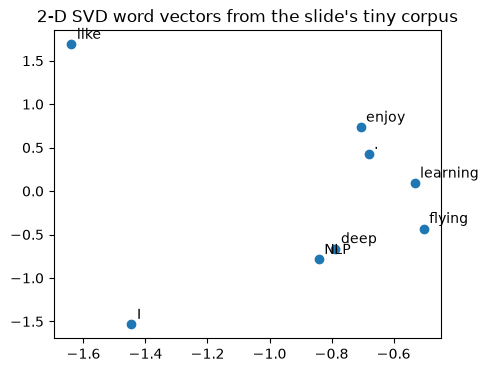

In [12]:
U_, S_, Vt_ = np.linalg.svd(X_toy.astype(float))
print("singular values:", S_.round(2))
for k in [1, 2, 4, 8]:
    Xk = U_[:, :k] @ np.diag(S_[:k]) @ Vt_[:k]
    print(f"rank {k}: Frobenius error = {np.linalg.norm(X_toy - Xk):.3f}   (= sqrt(sum of dropped s^2) = {np.sqrt((S_[k:]**2).sum()):.3f})")

W2 = U_[:, :2] * S_[:2]
plt.figure(figsize=(5, 4)); plt.scatter(W2[:, 0], W2[:, 1])
for (x, y), w in zip(W2, order):
    plt.annotate(w, (x, y), xytext=(4, 4), textcoords="offset points")
plt.title("2-D SVD word vectors from the slide's tiny corpus"); plt.show()

### 4.4 Hacks to $X$ (several used in Rohde et al. 2005, the COALS model)
**Running an SVD on raw counts doesn't work well!** Scaling the counts helps a lot. The problem is that function words (*the, he, has*) are too frequent, so syntax has too much impact. Some fixes:
* take the **log** of the frequencies
* **cap** counts: $\min(X, t)$ with $t\approx100$
* ignore the function words
* **ramped windows** that count closer words more than farther ones
* use **Pearson correlations** instead of counts, then set negative values to 0

With these, COALS found interesting semantic patterns: e.g., in the vector space, the offset *drive → driver* is parallel to *teach → teacher*, *swim → swimmer*, *clean → janitor*. **A meaning component ("doer of the event") becomes a linear direction in the space!** This is the same phenomenon as word2vec analogies, found with counts.

### 4.5 🔎 Beyond the slides: PPMI, the standard count transform
The most widely used fix is **positive pointwise mutual information**:

$$\text{PMI}(w,c) = \log\frac{P(w,c)}{P(w)P(c)}, \qquad \text{PPMI}(w,c) = \max(\text{PMI}(w,c), 0)$$

PMI asks: *do $w$ and $c$ co-occur more often than they would by chance?* It automatically down-weights frequent function words (their $P(c)$ is large). Negative values (co-occurring *less* than chance) are unreliable with finite data, so we clip them to 0. Below: PPMI + SVD on our toy corpus.

In [13]:
X = np.zeros((V_size, V_size))
for c, o in pairs:
    X[c, o] += 1                                  # symmetric window counts, window = 2

def ppmi(X):
    total = X.sum()
    p_w = X.sum(1, keepdims=True) / total
    p_c = X.sum(0, keepdims=True) / total
    with np.errstate(divide="ignore"):
        pmi = np.log((X / total) / (p_w * p_c))
    return np.maximum(pmi, 0)                     # log(0) = -inf -> clipped to 0

def svd_vectors(M, k=20):
    U_, S_, _ = np.linalg.svd(M, full_matrices=False)
    return U_[:, :k] * S_[:k]

E_raw  = normalize(svd_vectors(X))
E_log  = normalize(svd_vectors(np.log1p(X)))
E_ppmi = normalize(svd_vectors(ppmi(X)))
for word in ["crown", "loan"]:
    for name, E in [("raw counts", E_raw), ("log(1+X)", E_log), ("PPMI", E_ppmi)]:
        print(f"{name:11s} {word:5s} ->", [w for w, _ in most_similar(E, word)])
    print()

raw counts  crown -> ['kingdom', 'bank_river', 'reached', 'swim', 'of']
log(1+X)    crown -> ['kingdom', 'throne', 'boat', 'swim', 'loan']
PPMI        crown -> ['kingdom', 'prince', 'king', 'princess', 'queen']

raw counts  loan  -> ['stream', 'bank_river', 'reached', 'of', 'kingdom']
log(1+X)    loan  -> ['boat', 'stream', 'throne', 'swim', 'field']
PPMI        loan  -> ['bank', 'bank_money', 'boat', 'bank_river', 'rates']



With raw counts, the neighbors are a mess: "loan" lands next to *stream, reached, of*, because the SVD spends its few dimensions modeling the largest counts (frequent words like *the, of*) rather than informative ones. Simple log scaling doesn't fix it on this corpus, but PPMI, which normalizes by how frequent each word is on its own, gives clean semantic neighbors (*crown → kingdom, prince, king*; *loan → bank, bank_money, rates*). **Lesson: the weighting of the counts matters as much as the factorization.**

### 4.6 Count-based vs. prediction-based (the GloVe paper's framing)
| Count-based (LSA, HAL, COALS, PPMI-SVD) | Direct prediction (word2vec SG/CBOW, NNLM) |
|---|---|
| ✅ fast training | ✅ improved performance on other tasks |
| ✅ efficient use of global statistics | ✅ can capture complex patterns beyond similarity |
| ❌ mainly captures word similarity | ❌ scales with corpus size |
| ❌ disproportionate importance given to large counts | ❌ inefficient use of statistics (sees each co-occurrence one at a time) |

GloVe tries to get the best of both.

---
## 5. GloVe (Pennington, Socher & Manning, EMNLP 2014)

### 5.1 Crucial insight: ratios of co-occurrence probabilities encode meaning components
Consider the words *ice* and *steam*, and probe words $x$:

| | $x$ = solid | $x$ = gas | $x$ = water | $x$ = fashion |
|---|---|---|---|---|
| $P(x\mid\text{ice})$ | $1.9\times10^{-4}$ | $6.6\times10^{-5}$ | $3.0\times10^{-3}$ | $1.7\times10^{-5}$ |
| $P(x\mid\text{steam})$ | $2.2\times10^{-5}$ | $7.8\times10^{-4}$ | $2.2\times10^{-3}$ | $1.8\times10^{-5}$ |
| $\dfrac{P(x\mid\text{ice})}{P(x\mid\text{steam})}$ | **8.9** (large) | **$8.5\times10^{-2}$** (small) | **1.36** (≈1) | **0.96** (≈1) |

The raw probabilities are all small and hard to interpret. But the **ratio** cleanly isolates the meaning component that distinguishes ice from steam (solid vs. gas), and is ≈1 for words that relate to both (*water*) or neither (*fashion*).

### 5.2 Turning ratios into linear components
**Q:** How can we capture ratios of co-occurrence probabilities as *linear* meaning components in a word vector space?

**A: a log-bilinear model.** Make dot products equal log co-occurrence probabilities:
$$w_i\cdot w_j = \log P(i\mid j)$$
Then **vector differences** give log-ratios, which is exactly the analogy structure:
$$w_x\cdot(w_a - w_b) = \log\frac{P(x\mid a)}{P(x\mid b)}$$

### 5.3 The GloVe loss
$$\boxed{J = \sum_{i,j=1}^{|V|} f(X_{ij})\left(w_i^\top\tilde w_j + b_i + \tilde b_j - \log X_{ij}\right)^2}$$

* A **weighted least-squares** regression of the dot product onto **log counts**, over all **nonzero** entries of $X$ (fast: just one pass to collect counts, then train on the $\le |V|^2$ nonzero cells, independent of corpus size).
* $w$ and $\tilde w$ are "center" and "context" vectors (like $v$ and $u$); use $w+\tilde w$ at the end. $b, \tilde b$ are biases absorbing word frequency.
* Weighting function $f(x) = (x/x_{\max})^{\alpha}$ if $x<x_{\max}$, else $1$, with $\alpha=3/4$, $x_{\max}=100$. It **ignores zero counts** ($f(0)=0$, avoiding $\log 0$), **down-weights rare noisy co-occurrences**, and **caps** very frequent ones so "the" doesn't dominate.

Properties: fast training, scalable to huge corpora, good performance even with a small corpus and small vectors.

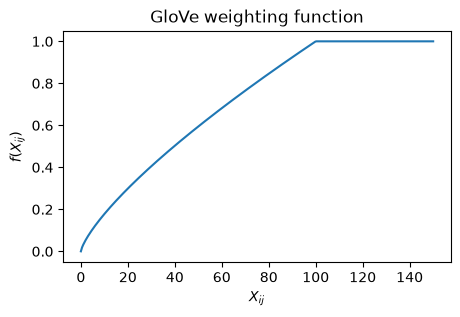

In [14]:
x = np.linspace(0, 150, 300)
plt.figure(figsize=(5, 3))
plt.plot(x, np.minimum(1, (x / 100) ** 0.75))
plt.xlabel("$X_{ij}$"); plt.ylabel("$f(X_{ij})$"); plt.title("GloVe weighting function"); plt.show()

In [15]:
def train_glove(X, d=10, x_max=100, alpha=0.75, lr=0.05, epochs=50, batch=512, seed=0):
    # GloVe with AdaGrad, as in the original implementation.
    r = np.random.default_rng(seed)
    V_ = X.shape[0]
    ii, jj = np.nonzero(X)                        # only nonzero co-occurrences
    logx = np.log(X[ii, jj])
    fx = np.minimum(1.0, (X[ii, jj] / x_max) ** alpha)
    W, Wt = (r.random((V_, d)) - 0.5) / d, (r.random((V_, d)) - 0.5) / d
    b, bt = np.zeros(V_), np.zeros(V_)
    # AdaGrad accumulators (initialized to 1 as in the reference code)
    GW, GWt, Gb, Gbt = np.ones((V_, d)), np.ones((V_, d)), np.ones(V_), np.ones(V_)
    losses = []
    for ep in range(epochs):
        perm, total = r.permutation(len(ii)), 0.0
        for k in range(0, len(perm), batch):
            idx = perm[k:k + batch]
            i, j = ii[idx], jj[idx]
            diff = np.sum(W[i] * Wt[j], 1) + b[i] + bt[j] - logx[idx]
            total += 0.5 * np.sum(fx[idx] * diff**2)
            g = fx[idx] * diff                     # dJ/d(prediction), up to a factor 2
            gW, gWt = g[:, None] * Wt[j], g[:, None] * W[i]
            np.add.at(GW, i, gW**2);  np.add.at(GWt, j, gWt**2)
            np.add.at(Gb, i, g**2);   np.add.at(Gbt, j, g**2)
            np.add.at(W, i, -lr * gW / np.sqrt(GW[i]));   np.add.at(Wt, j, -lr * gWt / np.sqrt(GWt[j]))
            np.add.at(b, i, -lr * g / np.sqrt(Gb[i]));    np.add.at(bt, j, -lr * g / np.sqrt(Gbt[j]))
        losses.append(total / len(ii))
    return W, Wt, losses

W_g, Wt_g, glove_losses = train_glove(X)
E_glove = W_g + Wt_g
E_glove = normalize(E_glove - E_glove.mean(0))    # mean-centering helps cosine on small corpora
print(f"nonzero cells trained on: {np.count_nonzero(X):,} (vs {len(pairs):,} skip-gram pairs)")
print("final loss:", round(glove_losses[-1], 4))
for w in ["king", "cat", "apple"]:
    print(f"{w:6s} ->", most_similar(E_glove, w))

nonzero cells trained on: 670 (vs 166,012 skip-gram pairs)
final loss: 0.0425
king   -> [('princess', 0.99), ('queen', 0.99), ('prince', 0.98), ('woman', 0.9), ('girl', 0.84)]
cat    -> [('horse', 0.99), ('dog', 0.97), ('cow', 0.96), ('village', 0.74), ('palace', 0.69)]
apple  -> [('mango', 0.99), ('orange', 0.99), ('banana', 0.98), ('fruit', 0.92), ('animal', 0.86)]


### 5.4 🔎 Beyond the slides: count vs. predict are secretly the same thing
Levy & Goldberg (2014) proved that SGNS, at its optimum, factorizes a **shifted PMI matrix**:
$$u_c^\top v_w = \text{PMI}(w,c) - \log K$$
So word2vec is *implicitly* doing matrix factorization of a reweighted co-occurrence matrix, very close to PPMI-SVD and GloVe. Much of the difference in practice comes from **hyperparameters** (window, subsampling, context distribution smoothing, using $w+\tilde w$), not the algorithm family (Levy, Goldberg & Dagan 2015). Our toy results agree: all three methods produce similar neighbors.

---
## 6. How to evaluate word vectors?

A general concept of evaluation in NLP: **intrinsic vs. extrinsic.**

| | Intrinsic | Extrinsic |
|---|---|---|
| What | Evaluate on a specific / intermediate subtask | Evaluate on a real task (e.g., NER, QA) |
| Speed | Fast to compute | Can take a long time |
| Insight | Helps understand the subsystem | Unclear whether the subsystem is the problem, or its interaction with other subsystems |
| Caveat | Not clear it's helpful unless correlation to a real task is established | If replacing exactly one subsystem with another improves accuracy → **winning!** |

### 6.1 Intrinsic evaluation 1: word vector analogies
$a:b :: c:\ ?$ e.g., *man:woman :: king:?* Answer with the word whose vector is most cosine-similar to $b - a + c$ (this rule is called **3CosAdd**):

$$d = \arg\max_i \frac{(x_b - x_a + x_c)^\top x_i}{\|x_b - x_a + x_c\|}$$

* **Discard the input words from the search (!!!).** The slide uses three exclamation marks for a reason: without it, the answer is very often just $b$ or $c$ itself, as you'll see below. Many published analogy results quietly depend on this.
* **Problem:** what if the information is there but **not linear**? Analogy tests only reward linear structure.
* Datasets: Google analogy set (semantic: *capital-country, family*; syntactic: *tall:tallest, walk:walked*), BATS, MSR.

In [16]:
def analogy(E, a, b, c, exclude_inputs=True, k=3):
    target = E[w2i[b]] - E[w2i[a]] + E[w2i[c]]
    sims = E @ (target / np.linalg.norm(target))
    if exclude_inputs:
        for w in (a, b, c):
            sims[w2i[w]] = -np.inf
    return [vocab[i] for i in np.argsort(-sims)[:k]]

questions = [("man", "king", "woman", "queen"), ("boy", "prince", "girl", "princess"),
             ("man", "boy", "woman", "girl"), ("cat", "animal", "apple", "fruit")]
for name, E in [("SGNS", E_sgns), ("PPMI-SVD", E_ppmi), ("GloVe", E_glove)]:
    ok = sum(analogy(E, a, b, c)[0] == d for a, b, c, d in questions)
    ok_noex = sum(analogy(E, a, b, c, exclude_inputs=False)[0] == d for a, b, c, d in questions)
    print(f"{name:9s} accuracy: {ok}/{len(questions)} with exclusion, {ok_noex}/{len(questions)} WITHOUT exclusion")

print("\nman:boy :: woman:?  without exclusion ->", analogy(E_sgns, "man", "boy", "woman", exclude_inputs=False),
      "  <- the top answer is the input word 'woman' itself")
print("cat:animal :: apple:? with exclusion  ->", analogy(E_sgns, "cat", "animal", "apple"),
      "  <- 'fruit' is related, but the relation isn't captured as a clean linear offset here")

SGNS      accuracy: 3/4 with exclusion, 2/4 WITHOUT exclusion
PPMI-SVD  accuracy: 3/4 with exclusion, 2/4 WITHOUT exclusion
GloVe     accuracy: 2/4 with exclusion, 1/4 WITHOUT exclusion

man:boy :: woman:?  without exclusion -> ['woman', 'girl', 'works']   <- the top answer is the input word 'woman' itself
cat:animal :: apple:? with exclusion  -> ['ripe', 'orange', 'banana']   <- 'fruit' is related, but the relation isn't captured as a clean linear offset here


### 6.2 Intrinsic evaluation 2: similarity vs. human judgments
Compute cosine similarity for word pairs and measure **Spearman rank correlation** with human similarity ratings. Example data from **WordSim353**:

| Word 1 | Word 2 | Human (mean, 0–10) |
|---|---|---|
| tiger | cat | 7.35 |
| tiger | tiger | 10 |
| book | paper | 7.46 |
| computer | internet | 7.58 |
| plane | car | 5.77 |
| professor | doctor | 6.62 |
| stock | phone | 1.62 |
| stock | CD | 1.31 |
| stock | jaguar | 0.92 |

Results from the GloVe paper (Spearman ×100, 300-d vectors; "6B" = training tokens):

| Model | Size | WS353 | MC | RG | SCWS | RW |
|---|---|---|---|---|---|---|
| SVD | 6B | 35.3 | 35.1 | 42.5 | 38.3 | 25.6 |
| SVD-S (√ counts) | 6B | 56.5 | 71.5 | 71.0 | 53.6 | 34.7 |
| SVD-L (log counts) | 6B | 65.7 | 72.7 | 75.1 | 56.5 | 37.0 |
| CBOW | 6B | 57.2 | 65.6 | 68.2 | 57.0 | 32.5 |
| SG | 6B | 62.8 | 65.2 | 69.7 | 58.1 | 37.2 |
| GloVe | 6B | 65.8 | 72.7 | 77.8 | 53.9 | 38.1 |
| GloVe | 42B | 75.9 | 83.6 | 82.9 | 59.6 | 47.8 |
| CBOW (word2vec site) | 100B | 68.4 | 79.6 | 75.4 | 59.4 | 45.5 |

Note how **raw SVD is terrible** and scaled SVD (log counts) is competitive, exactly what we saw in §4.5. And more data helps a lot (6B → 42B).

Below we do the same procedure with a **made-up** mini "human judgment" set for our toy vocabulary (the scores are invented just to demonstrate the mechanics):

In [17]:
toy_judgments = [("king", "queen", 8.5), ("king", "prince", 9.0), ("cat", "dog", 8.0), ("horse", "cow", 8.0),
                 ("apple", "banana", 8.0), ("man", "woman", 7.5), ("palace", "throne", 6.5), ("king", "man", 6.0),
                 ("market", "village", 5.0), ("cat", "apple", 1.5), ("king", "banana", 0.5), ("throne", "grass", 1.0),
                 ("dog", "crown", 0.8), ("mango", "loan", 0.3)]
human = [s for _, _, s in toy_judgments]
for name, E in [("SGNS", E_sgns), ("PPMI-SVD", E_ppmi), ("raw-SVD", E_raw), ("GloVe", E_glove)]:
    model_sims = [float(E[w2i[a]] @ E[w2i[b]]) for a, b, _ in toy_judgments]
    rho = spearmanr(human, model_sims).correlation
    print(f"{name:9s} Spearman rho = {rho:.3f}")

SGNS      Spearman rho = 0.832
PPMI-SVD  Spearman rho = 0.885
raw-SVD   Spearman rho = 0.872
GloVe     Spearman rho = 0.845


On this tiny, very regular corpus all methods score similarly (even raw SVD), because there's little noise for the weighting to fix, and 14 invented pairs is a statistically meaningless test set. On real corpora, the differences are large (see the GloVe table above: raw SVD 35.3 vs. log-scaled SVD 65.7 on WS353). **A general lesson about evaluation:** small or easy benchmarks can't distinguish good methods from bad ones.

### 6.3 What the GloVe paper found about hyperparameters
* **Dimension:** gains flatten around **~300**.
* **Window:** symmetric windows of size ~8 work well. Smaller windows → more syntactic information, larger → more semantic.
* **More data helps**, and **Wikipedia is better than news text** (Wiki2014 at 1.6B tokens beats Gigaword5 at 4.3B on analogies). An encyclopedia explains what words mean, and it is updated over time, whereas Gigaword is a fixed news archive with outdated information.
* **Training time:** more iterations help GloVe.

### 6.4 Extrinsic evaluation: named entity recognition
A task where good word vectors should help directly: **NER**, finding references to a person, organization, or location: *[Chris Manning]PER lives in [Palo Alto]LOC*. From the GloVe paper (F1, 50-d vectors added as features to a CRF tagger):

| Model | Dev | Test | ACE | MUC7 |
|---|---|---|---|---|
| Discrete (no word vectors) | 91.0 | 85.4 | 77.4 | 73.4 |
| SVD | 90.8 | 85.7 | 77.3 | 73.7 |
| CBOW | 93.1 | 88.2 | 82.2 | 81.1 |
| GloVe | 93.2 | 88.3 | 82.9 | 82.2 |

Good vectors → +3 F1 on test, +8 on MUC7. We build a (neural) NER classifier in §8–9.

---
## 7. Word senses and word-sense ambiguity

Most words have lots of meanings! Especially **common** words, and words that have existed for a long time. Example, **pike**:
* a sharp point or staff · a type of elongated fish · a railroad line or system · a type of road · the future (*coming down the pike*) · a body position in diving · to kill or pierce with a pike · to make one's way (*pike along*) · in Australian English, to pull out of doing something (*"I reckon he could have climbed that cliff, but he piked!"*)

**Does one vector capture all these meanings, or do we have a mess?**

### 7.1 Multiple prototypes (Huang et al. 2012)
**Idea:** cluster the context windows around each occurrence of a word, then retrain with each word occurrence assigned to its cluster: *bank₁, bank₂, …* Each sense gets its own vector.

Let's try this on our ambiguous `bank` tokens. We represent each occurrence by the **average of its context word vectors**, then run k-means with $k=2$, and check against the true sense (which we know from the template).

In [ ]:
river_words = {"river", "stream", "boat", "fish", "muddy", "swim"}
occ_vecs, occ_true = [], []
for s in corpus:
    for t, w in enumerate(s):
        if w == "bank":
            ctx = [s[j] for j in range(max(0, t - 3), min(len(s), t + 4)) if j != t]
            occ_vecs.append(np.mean([E_sgns[w2i[c]] for c in ctx], axis=0))
            occ_true.append(int(any(c in river_words for c in s)))       # 1 = river sense
occ_vecs, occ_true = np.array(occ_vecs), np.array(occ_true)

def kmeans(Xk, k=2, iters=20, seed=0):
    r = np.random.default_rng(seed)
    C = Xk[r.choice(len(Xk), k, replace=False)]
    for _ in range(iters):
        assign = np.argmin(((Xk[:, None, :] - C[None]) ** 2).sum(-1), axis=1)
        C = np.array([Xk[assign == j].mean(0) for j in range(k)])
    return assign

assign = kmeans(occ_vecs)
acc = max(np.mean(assign == occ_true), np.mean(assign != occ_true))   # cluster ids are arbitrary
print(f"{len(occ_true)} occurrences of ambiguous 'bank'; {occ_true.mean():.0%} are the river sense")
print(f"k-means sense induction agrees with the true senses on {acc:.1%} of occurrences")

### 7.2 Linear algebraic structure of word senses (Arora, Li, Liang, Ma & Risteski, TACL 2018)
Different senses of a word reside in a **linear superposition** (weighted sum) in standard embeddings like word2vec:
$$v_{\text{pike}} = \alpha_1 v_{\text{pike}_1} + \alpha_2 v_{\text{pike}_2} + \alpha_3 v_{\text{pike}_3}, \qquad \alpha_1 = \frac{f_1}{f_1+f_2+f_3},\ \text{etc.}$$
where $f_i$ is the frequency of sense $i$. **Surprising result:** because of ideas from **sparse coding**, you can actually separate out the senses (provided they're relatively common)!

Our corpus lets us test this directly: we have vectors for the "pure" senses `bank_money` and `bank_river`, and for the ambiguous `bank`. Is $v_{\text{bank}} \approx \alpha_1 v_{\text{money}} + \alpha_2 v_{\text{river}}$?

In [ ]:
E_raw_sgns = Vc_sg + U_sg                       # unnormalized vectors for this test
A = np.stack([E_raw_sgns[w2i["bank_money"]], E_raw_sgns[w2i["bank_river"]]], axis=1)   # (d, 2)
target = E_raw_sgns[w2i["bank"]]
alpha, *_ = np.linalg.lstsq(A, target, rcond=None)
recon = A @ alpha
cos = recon @ target / (np.linalg.norm(recon) * np.linalg.norm(target))
print(f"least-squares fit: v_bank ~ {alpha[0]:.2f} * v_money + {alpha[1]:.2f} * v_river")
print(f"cosine(v_bank, reconstruction) = {cos:.3f}")
print(f"relative weight of money sense = {alpha[0]/alpha.sum():.2f}  (true sense frequency = 0.70)")
cs = lambda a, b: float(E_sgns[w2i[a]] @ E_sgns[w2i[b]])
print(f"cos(money, river) = {cs('bank_money','bank_river'):.2f}  -> the two senses are nearly unrelated,")
print(f"yet cos(bank, money) = {cs('bank','bank_money'):.2f} and cos(bank, river) = {cs('bank','bank_river'):.2f}: 'bank' sits between them")

The ambiguous vector is well explained as a weighted mix of the sense vectors, with more weight on the more frequent sense, just as the paper says. (On a toy corpus the weights won't match frequencies exactly.)

### 7.3 🔎 Where this leads: contextual embeddings
Static vectors force one point per word type. The modern answer is to compute a **different vector for each token occurrence**, as a function of its sentence: ELMo (2018), then BERT and every Transformer LM. "bank" in *river bank* and *bank loan* get different vectors automatically. You'll see this in Lectures 8–9. The "average of context vectors" we used for clustering above is a (very) crude contextual embedding.

---
## 8. Deep learning classification: Named Entity Recognition (NER)

**The task:** find and classify names in text, by labeling word tokens:

```
Last night , Paris Hilton wowed in a sequin gown .
             PER   PER
Samuel Quinn was arrested in the Hilton Hotel in Paris in April 1989 .
PER    PER                       LOC    LOC      LOC      DATE  DATE
```

Note *Paris* is a person in the first sentence and a location in the second: **context decides.**

**Possible uses:** tracking mentions of particular entities in documents; question answering (answers are usually named entities); relating sentiment to the entity under discussion. Often followed by **entity linking** (canonicalization) into a knowledge base such as Wikidata.

### 8.1 Simple NER: window classification
**Idea:** classify each word *in its context window* of neighboring words. Train a classifier on hand-labeled data to classify the center word {yes/no} for each class, based on a **concatenation of word vectors in a window**.

Example: classify *Paris* as ± location, with window length 2:

*the museums in **Paris** are amazing to see .*

$$x_{\text{window}} = [\,x_{\text{museums}}\ \ x_{\text{in}}\ \ x_{\text{Paris}}\ \ x_{\text{are}}\ \ x_{\text{amazing}}\,]^\top \in \mathbb{R}^{5d}$$

To classify all words, run the classifier on the window centered on each word in the sentence (padding at the edges). Really we'd usually use a multi-class softmax over {PER, LOC, ORG, O, …}.

In [18]:
def windows(tokens, m=2, pad="<pad>"):
    # Return one window of 2m+1 tokens for each position (padded at the edges).
    padded = [pad] * m + tokens + [pad] * m
    return [padded[t:t + 2 * m + 1] for t in range(len(tokens))]

for w in windows("the museums in paris are amazing to see .".split()):
    print(w)

['<pad>', '<pad>', 'the', 'museums', 'in']
['<pad>', 'the', 'museums', 'in', 'paris']
['the', 'museums', 'in', 'paris', 'are']
['museums', 'in', 'paris', 'are', 'amazing']
['in', 'paris', 'are', 'amazing', 'to']
['paris', 'are', 'amazing', 'to', 'see']
['are', 'amazing', 'to', 'see', '.']
['amazing', 'to', 'see', '.', '<pad>']
['to', 'see', '.', '<pad>', '<pad>']


### 8.2 Classification review and notation
* Supervised learning: a training set $\{x_i, y_i\}_{i=1}^N$.
* $x_i$ are inputs (words as indices or vectors, sentences, documents), dimension $d$.
* $y_i$ are labels, one of $C$ classes (sentiment +/−, named entities, buy/sell, other words, later multi-word sequences).

**A typical ML/stats softmax classifier:** with $W\in\mathbb{R}^{C\times d}$,
$$p(y\mid x) = \frac{\exp(W_{y}\cdot x)}{\sum_{c=1}^{C}\exp(W_c\cdot x)}$$
* The learned parameters $\theta$ are **just the elements of $W$**, not the input representation $x$ (which is sparse symbolic features).
* It gives a **linear decision boundary**, which can be limiting.

### 8.3 Training with cross-entropy loss
So far our objective was to maximize the probability of the correct class $y$, i.e., minimize $-\log p(y\mid x)$. This is restated with **cross-entropy** from information theory. With true distribution $p$ and model distribution $q$:
$$H(p, q) = -\sum_{c=1}^{C} p(c)\log q(c)$$
With a one-hot ground truth (gold) $p = [0,\dots,0,1,0,\dots,0]$, the only surviving term is $-\log q(y_i)$, the negative log probability of the true class. **In PyTorch: `torch.nn.CrossEntropyLoss()`** (it takes raw logits and applies log-softmax internally).

🔎 Cross-entropy with a "more interesting $p$" appears later: **label smoothing** (put $1-\epsilon$ on the true class and spread $\epsilon$ over the others) and **knowledge distillation** (use a teacher model's distribution as $p$).

In [ ]:
q = softmax(np.array([2.0, 0.5, -1.0]))       # model distribution over 3 classes
p_onehot = np.array([1.0, 0.0, 0.0])
H = -(p_onehot * np.log(q)).sum()
print(f"q = {q},  H(p,q) = {H:.4f},  -log q[true] = {-np.log(q[0]):.4f}  (identical)")

eps = 0.1
p_smooth = (1 - eps) * p_onehot + eps / 3
print(f"label-smoothed target {p_smooth.round(3)} -> H = {-(p_smooth * np.log(q)).sum():.4f}")

### 8.4 The limitation of linear classifiers, visualized
A softmax classifier trained on a 3-class spiral. The gradient is the same $(\hat y - y)$ form as word2vec: $\nabla_W J = (\hat Y - Y)^\top X / N$.

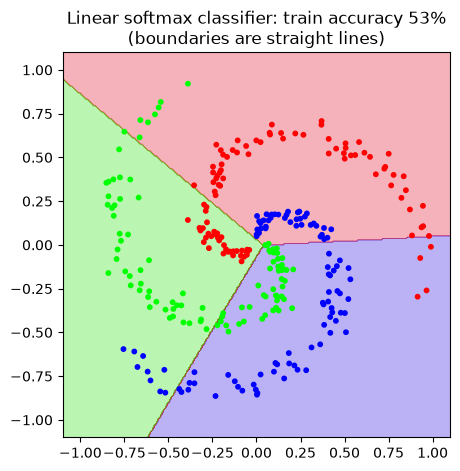

In [19]:
def make_spiral(n=100, C=3, seed=0):
    r = np.random.default_rng(seed)
    Xs, ys = [], []
    for c in range(C):
        rad = np.linspace(0.05, 1, n)
        ang = np.linspace(c * 4, (c + 1) * 4, n) + r.normal(scale=0.2, size=n)
        Xs.append(np.c_[rad * np.sin(ang), rad * np.cos(ang)]); ys.append(np.full(n, c))
    return np.vstack(Xs), np.concatenate(ys)

Xsp, ysp = make_spiral()
Xb = np.c_[Xsp, np.ones(len(Xsp))]               # append the "always on" bias feature
Y1 = np.eye(3)[ysp]
Wsm = np.zeros((3, 3))
for step in range(2000):
    P = softmax(Xb @ Wsm.T)
    Wsm -= 1.0 * (P - Y1).T @ Xb / len(Xb)
acc = (np.argmax(Xb @ Wsm.T, 1) == ysp).mean()

gx, gy = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
grid = np.c_[gx.ravel(), gy.ravel(), np.ones(gx.size)]
plt.figure(figsize=(5, 5))
plt.contourf(gx, gy, np.argmax(grid @ Wsm.T, 1).reshape(gx.shape), alpha=0.3, cmap="brg")
plt.scatter(Xsp[:, 0], Xsp[:, 1], c=ysp, cmap="brg", s=10)
plt.title(f"Linear softmax classifier: train accuracy {acc:.0%}\n(boundaries are straight lines)"); plt.show()

### 8.5 Neural classification: what's different?
A neural network classifier differs in that:
1. **We learn both $W$ and (distributed!) representations for words.** The word vectors $x$ re-represent one-hot vectors, moving them around in an intermediate vector space for easy classification with a (linear) softmax classifier. Conceptually we have an **embedding layer**: $x = Le$, where $L$ is the embedding matrix and $e$ a one-hot vector.
2. **We use deep networks (more layers)** that let us re-represent and compose our data multiple times, giving a **non-linear** classifier. (But typically it is still *linear relative to the pre-final layer representation*.)

### 8.6 NER as a binary neural classifier for "center word is a location"
$$x = [\,x_{\text{museums}}\ x_{\text{in}}\ x_{\text{Paris}}\ x_{\text{are}}\ x_{\text{amazing}}\,] \in \mathbb{R}^{5d}$$
$$h = f(Wx + b),\qquad s = u^\top h,\qquad J_t(\theta) = \sigma(s) = \frac{1}{1+e^{-s}}$$
* $f$ is some elementwise non-linearity (logistic, tanh, ReLU).
* $\sigma(s)$ is the predicted model probability of the class; we do supervised training and want it high if the center word is a location.

Shapes for $d$-dim word vectors and hidden size $n$: $x\in\mathbb{R}^{5d}$, $W\in\mathbb{R}^{n\times 5d}$, $b\in\mathbb{R}^n$, $h\in\mathbb{R}^n$, $u\in\mathbb{R}^n$, $s\in\mathbb{R}$. Let's run the forward pass in NumPy to make the shapes concrete. (Lecture 3 derives every gradient of this exact network by hand.)

In [ ]:
d, n_hidden = 4, 8
ner_vocab = ["<pad>", "the", "museums", "in", "paris", "are", "amazing", "to", "see", "."]
L = rng.normal(scale=0.1, size=(len(ner_vocab), d))       # embedding matrix (one row per word)
W = rng.normal(scale=0.1, size=(n_hidden, 5 * d)); b = np.zeros(n_hidden)
u = rng.normal(scale=0.1, size=n_hidden)

window = ["museums", "in", "paris", "are", "amazing"]
x = np.concatenate([L[ner_vocab.index(w)] for w in window])    # lookup + concat
z = W @ x + b
h = np.tanh(z)
s = u @ h
print("x:", x.shape, " W:", W.shape, " z = Wx+b:", z.shape, " h = f(z):", h.shape, " s = u.h:", np.shape(s))
print(f"P(location | window) = sigma(s) = {sigmoid(s):.4f}   (untrained, so ~0.5)")

---
## 9. Neural computation: from logistic regression to neural networks

### 9.1 A neuron is (roughly) a logistic regression unit
$$h_{w,b}(x) = f(w^\top x + b), \qquad f(z) = \frac{1}{1+e^{-z}}$$
$w, b$ are the parameters of this neuron (i.e., this logistic regression model). $b$ can be an "always on" bias feature that gives a class prior, or kept separate as a bias term. $f$ = nonlinear activation, $w$ = weights, $b$ = bias, $h$ = hidden, $x$ = inputs.

### 9.2 A neural network = running several logistic regressions at the same time
If we feed a vector of inputs through a bunch of logistic regression functions, we get a vector of outputs. **But we don't have to decide ahead of time what variables these logistic regressions are trying to predict!** We feed them into another logistic regression, and so on. **It is the final loss function that directs what the intermediate hidden variables should be**, so as to do a good job of predicting the targets for the next layer.

Before we know it, we have a multilayer neural network. It lets us re-represent and compose our data multiple times, and learn a classifier that is highly non-linear in the original inputs (but typically linear in the pre-final layer representation).

### 9.3 Matrix notation for a layer
$$a_1 = f(W_{11}x_1 + W_{12}x_2 + W_{13}x_3 + b_1),\quad a_2 = f(W_{21}x_1 + \dots + b_2),\ \dots$$
$$\Longrightarrow\quad z = Wx + b,\qquad a = f(z),\qquad f([z_1,z_2,z_3]) = [f(z_1), f(z_2), f(z_3)]$$
The activation $f$ is applied **element-wise**.

### 9.4 Why non-linearities are needed
Neural networks do function approximation (regression or classification). **Without non-linearities, deep neural networks can't do anything more than a linear transform**: extra layers could just be compiled down into a single linear transform, $W_1W_2x = Wx$. With non-linear layers, they can approximate (essentially) any function, the **universal approximation theorem** (🔎 Cybenko 1989; Hornik 1991).

In [21]:
W1, W2, W3 = rng.normal(size=(5, 4)), rng.normal(size=(6, 5)), rng.normal(size=(2, 6))
x_in = rng.normal(size=4)
deep_linear = W3 @ (W2 @ (W1 @ x_in))
W_collapsed = W3 @ W2 @ W1                   # a single 2x4 matrix
print("3 linear layers:", deep_linear)
print("1 linear layer :", W_collapsed @ x_in, " identical:", np.allclose(deep_linear, W_collapsed @ x_in))

relu = lambda z: np.maximum(z, 0)
deep_nonlin = W3 @ relu(W2 @ relu(W1 @ x_in))
print("with ReLU in between, no single matrix reproduces it for all x:", deep_nonlin)

3 linear layers: [-3.588 23.117]
1 linear layer : [-3.588 23.117]  identical: True
with ReLU in between, no single matrix reproduces it for all x: [ 0.056 -0.079]


### 9.5 Putting it together: a window-based neural NER tagger (PyTorch)
Now the full pipeline from the lecture: embedding layer → concatenate a window → hidden layer with non-linearity → softmax over classes, trained with `CrossEntropyLoss`. We use 3 classes: `O` (other), `PER`, `LOC`.

The tiny synthetic dataset deliberately includes the slide's ambiguity: **"paris" is a location in "… in paris ." but a person in "paris hilton wowed …"**. A model that only looked at the word itself could never get both right; the window makes it possible.

In [22]:
people = ["john", "mary", "samuel", "quinn", "alice"]
cities = ["paris", "london", "rome", "tokyo", "lagos"]
def ner_sentence():
    P, P2, C = random.choice(people), random.choice(people), random.choice(cities)
    templates = [
        (f"{P} lives in {C} .",                       ["PER", "O", "O", "LOC", "O"]),
        (f"the museums in {C} are amazing to see .",  ["O", "O", "O", "LOC", "O", "O", "O", "O", "O"]),
        (f"{P} flew to {C} last week .",              ["PER", "O", "O", "LOC", "O", "O", "O"]),
        (f"{P} met {P2} at the hilton hotel in {C} .", ["PER", "O", "PER", "O", "O", "LOC", "LOC", "O", "LOC", "O"]),
        ("last night , paris hilton wowed in a sequin gown .", ["O", "O", "O", "PER", "PER", "O", "O", "O", "O", "O", "O"]),
        (f"{P} said that {C} is beautiful .",         ["PER", "O", "O", "LOC", "O", "O", "O"]),
    ]
    s, tags = random.choice(templates)
    return s.split(), tags

random.seed(1)
ner_data = [ner_sentence() for _ in range(1500)]
assert all(len(s) == len(t) for s, t in ner_data)
ner_words = ["<pad>"] + sorted({w for s, _ in ner_data for w in s})
nw2i = {w: i for i, w in enumerate(ner_words)}
TAGS = ["O", "PER", "LOC"]

def to_examples(data, m=2):
    Xw, Yw = [], []
    for s, tags in data:
        for win, tag in zip(windows(s, m), tags):
            Xw.append([nw2i[w] for w in win]); Yw.append(TAGS.index(tag))
    return np.array(Xw), np.array(Yw)

X_ner, Y_ner = to_examples(ner_data)
print("windows:", X_ner.shape, " label counts:", dict(zip(TAGS, np.bincount(Y_ner))))
print("example window ids:", X_ner[3], "->", [ner_words[i] for i in X_ner[3]], "label", TAGS[Y_ner[3]])

windows: (12285, 5)  label counts: {'O': np.int64(8825), 'PER': np.int64(1761), 'LOC': np.int64(1699)}
example window ids: [ 9 33 24 17 35] -> ['flew', 'to', 'paris', 'last', 'week'] label LOC


In [24]:
# [PyTorch] Window-based neural NER classifier (embedding -> concat -> tanh hidden -> softmax).
import torch
import torch.nn as nn
import torch.nn.functional as F

class WindowNER(nn.Module):
    def __init__(self, vocab_size, n_classes, window=5, emb_dim=16, hidden=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)          # L
        self.hidden = nn.Linear(window * emb_dim, hidden)      # W, b
        self.out = nn.Linear(hidden, n_classes)                # U, b2 (multi-class version of u)

    def forward(self, win_ids):                    # (B, 5) word ids
        x = self.emb(win_ids).flatten(1)           # (B, 5*emb_dim): lookup + concatenate
        h = torch.tanh(self.hidden(x))             # h = f(Wx + b)
        return self.out(h)                         # logits; softmax lives inside the loss

torch.manual_seed(0)
Xt, Yt = torch.tensor(X_ner), torch.tensor(Y_ner)
n_train = int(0.8 * len(Xt))
model = WindowNER(len(ner_words), len(TAGS))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(5):
    perm = torch.randperm(n_train)
    for k in range(0, n_train, 64):
        idx = perm[k:k + 64]
        loss = loss_fn(model(Xt[idx]), Yt[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (model(Xt[n_train:]).argmax(1) == Yt[n_train:]).float().mean().item()
    print(f"epoch {epoch+1}: last batch loss {loss.item():.4f}, held-out accuracy {acc:.3f}")

def tag(sentence):
    toks = sentence.split()
    print(toks[0], toks[1])
    ids = torch.tensor([[nw2i.get(w, 0) for w in win] for win in windows(toks)])
    print(ids)
    with torch.no_grad():
        pred = model(ids).argmax(1).tolist()
    return " ".join(f"{w}/{TAGS[p]}" if TAGS[p] != "O" else w for w, p in zip(toks, pred))

print(tag("last night , paris hilton wowed in a sequin gown ."))
print(tag("alice flew to paris last week ."))

epoch 1: last batch loss 0.0004, held-out accuracy 1.000
epoch 2: last batch loss 0.0002, held-out accuracy 1.000
epoch 3: last batch loss 0.0001, held-out accuracy 1.000
epoch 4: last batch loss 0.0001, held-out accuracy 1.000
epoch 5: last batch loss 0.0000, held-out accuracy 1.000
last night
tensor([[ 0,  0, 17, 23,  1],
        [ 0, 17, 23,  1, 24],
        [17, 23,  1, 24, 11],
        [23,  1, 24, 11, 36],
        [ 1, 24, 11, 36, 13],
        [24, 11, 36, 13,  3],
        [11, 36, 13,  3, 30],
        [36, 13,  3, 30, 10],
        [13,  3, 30, 10,  2],
        [ 3, 30, 10,  2,  0],
        [30, 10,  2,  0,  0]])
last night , paris/PER hilton/PER wowed in a sequin gown .
alice flew
tensor([[ 0,  0,  4,  9, 33],
        [ 0,  4,  9, 33, 24],
        [ 4,  9, 33, 24, 17],
        [ 9, 33, 24, 17, 35],
        [33, 24, 17, 35,  2],
        [24, 17, 35,  2,  0],
        [17, 35,  2,  0,  0]])
alice/PER flew to paris/LOC last week .


---
## 10. Summary

| Topic | Takeaway |
|---|---|
| Two vectors per word | Easier optimization; average at the end |
| SG vs CBOW | Predict context from center vs. center from averaged context |
| Negative sampling | $-\log\sigma(u_o^\top v_c) - \sum_k\log\sigma(-u_k^\top v_c)$; negatives from $U(w)^{3/4}$ |
| Sparse updates | Only rows for words in the window (+ negatives) change |
| Count-based | Co-occurrence matrix + SVD; **scaling (log / PPMI) is essential** |
| GloVe | Weighted least squares: $w_i^\top\tilde w_j + b_i + \tilde b_j \approx \log X_{ij}$; ratios → linear components |
| Count ≈ predict | SGNS implicitly factorizes shifted PMI |
| Evaluation | Intrinsic (analogies with input exclusion; similarity Spearman) vs. extrinsic (NER F1) |
| Senses | One vector ≈ frequency-weighted superposition of sense vectors; multi-prototype clustering; contextual embeddings |
| Cross-entropy | $H(p,q)=-\sum p\log q$ → $-\log q(y)$ for one-hot $p$; `nn.CrossEntropyLoss` |
| Neural nets | Stacked logistic regressions; $z=Wx+b$, $a=f(z)$; non-linearities are essential |

### Exercises
1. Derive the SGNS gradients in §3.2 yourself, using only $\sigma'(x) = \sigma(x)(1-\sigma(x))$.
2. Change the negative-sampling power from 0.75 to 1.0 and 0.0 in `train_sgns`. Do neighbors for rare words get better or worse?
3. Implement **CBOW** with negative sampling (input = mean of the context vectors).
4. Run SVD on `np.minimum(X, 100)` (the clipping hack) and compare with PPMI.
5. In the NER model, change the window to $m=0$ (just the word itself). What happens to the two "paris" sentences, and why?
6. Read Levy, Goldberg & Dagan (2015), *Improving Distributional Similarity with Lessons Learned from Word Embeddings*, the best single paper for understanding why embedding methods differ.

### References
* Mikolov et al. 2013, *Distributed Representations of Words and Phrases and their Compositionality*.
* Pennington, Socher & Manning 2014, *GloVe: Global Vectors for Word Representation*.
* Rohde, Gonnerman & Plaut 2005, *An Improved Model of Semantic Similarity Based on Lexical Co-Occurrence* (COALS).
* Levy & Goldberg 2014, *Neural Word Embedding as Implicit Matrix Factorization*.
* Huang et al. 2012, *Improving Word Representations via Global Context and Multiple Word Prototypes*.
* Arora et al. 2018, *Linear Algebraic Structure of Word Senses, with Applications to Polysemy*.
* Collobert & Weston et al. 2011, *Natural Language Processing (almost) from Scratch* (window-based neural NER).

**Next:** Lecture 3, how to compute all those gradients: matrix calculus by hand, and backpropagation.